In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("eda_dataset.csv")

In [30]:
df = df.drop(columns=['location', 'notes'])

In [31]:
print("Missing values before cleaning:\n", df.isnull().sum())
df = df.dropna(subset=['text', 'category'])

Missing values before cleaning:
 text              26
amount            45
category          19
payment_method    15
dtype: int64


In [32]:
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
# Remove negative amounts and NaNs
df = df[(df['amount'] > 0) & (df['amount'].notnull())]

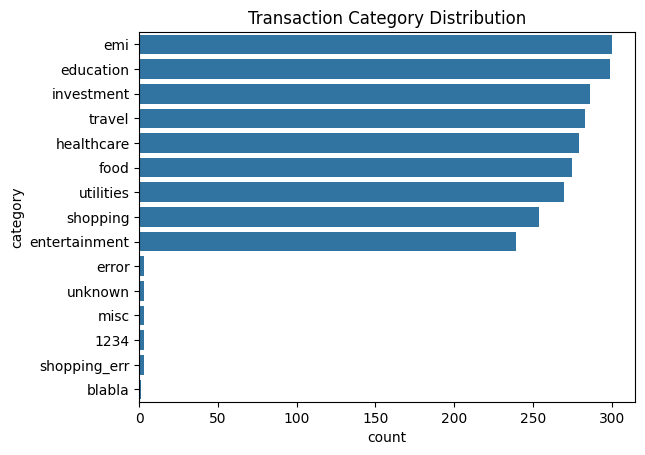

In [33]:
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
plt.title("Transaction Category Distribution")
plt.show()

**Colab Code: Training DistilBERT for Category Classification**

In [34]:
!pip install transformers datasets evaluate

In [35]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [36]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

In [37]:
train_df, val_df = train_test_split(df[['text', 'label']], test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

In [38]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

In [39]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(le.classes_)
)
# 5. Train
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.340315
2,No log,0.074612
3,No log,0.057949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=375, training_loss=0.5777841389973958, metrics={'train_runtime': 45.2323, 'train_samples_per_second': 132.649, 'train_steps_per_second': 8.291, 'total_flos': 99373582080000.0, 'train_loss': 0.5777841389973958, 'epoch': 3.0})

** The Final Inference Pipeline**

In [40]:
import re
import torch

In [41]:
def extract_transaction_info(text):
    # 1. Predict Category (DistilBERT)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to('cuda')
    with torch.no_grad():
        outputs = model(**inputs)
    category_id = torch.argmax(outputs.logits, dim=1).item()
    category = le.inverse_transform([category_id])[0]

    # 2. Extract Amount (Regex & Multipliers)
    amount = None
    lower_text = text.lower()

    # Check for multiplier words (e.g. "do hazaar")
    multipliers = {"hazaar": 1000, "sau": 100, "lakh": 100000}
    for word, factor in multipliers.items():
        match = re.search(rf'(\d+\.?\d*)\s*{word}', lower_text)
        if match:
            amount = float(match.group(1)) * factor
            break

    # Fallback to standard numbers
    if not amount:
        numbers = re.findall(r'\b(\d[\d,]*\.?\d*)\b', lower_text)
        if numbers:
            amount = float(numbers[0].replace(',', ''))

    return {
        "text": text,
        "amount": amount,
        "category": category
    }
# Test the pipeline
print(extract_transaction_info("Bhai Swiggy se pizza mangwaya 450 rupaye ka"))
# Out: {'text': '...', 'amount': 450.0, 'category': 'food'}

{'text': 'Bhai Swiggy se pizza mangwaya 450 rupaye ka', 'amount': 450.0, 'category': 'food'}
